1. Pitanje - je li podrucje skupo? 0 - nije skupo; 1 - je skupo
2. Ako je podrucje skupo, kolika je ocekivana cijena kuca u tom podrucju?

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, mean_absolute_error, r2_score)

pd.set_option('display.float_format', '{:,.2f}'.format)

In [4]:
housing = fetch_california_housing()
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [6]:
df = pd.DataFrame(housing['data'])
df

,0,1,2,3,4,5,6,7
0,8.33,41.00,6.98,1.02,322.00,2.56,37.88,-122.23
1,8.30,21.00,6.24,0.97,"2,401.00",2.11,37.86,-122.22
2,7.26,52.00,8.29,1.07,496.00,2.80,37.85,-122.24
3,5.64,52.00,5.82,1.07,558.00,2.55,37.85,-122.25
4,3.85,52.00,6.28,1.08,565.00,2.18,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.56,25.00,5.05,1.13,845.00,2.56,39.48,-121.09
20636,2.56,18.00,6.11,1.32,356.00,3.12,39.49,-121.21
20637,1.70,17.00,5.21,1.12,"1,007.00",2.33,39.43,-121.22
20638,1.87,18.00,5.33,1.17,741.00,2.12,39.43,-121.32


In [8]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.33,41.00,6.98,1.02,322.00,2.56,37.88,-122.23,4.53
1,8.30,21.00,6.24,0.97,"2,401.00",2.11,37.86,-122.22,3.58
2,7.26,52.00,8.29,1.07,496.00,2.80,37.85,-122.24,3.52
3,5.64,52.00,5.82,1.07,558.00,2.55,37.85,-122.25,3.41
4,3.85,52.00,6.28,1.08,565.00,2.18,37.85,-122.25,3.42
...,...,...,...,...,...,...,...,...,...
20635,1.56,25.00,5.05,1.13,845.00,2.56,39.48,-121.09,0.78
20636,2.56,18.00,6.11,1.32,356.00,3.12,39.49,-121.21,0.77
20637,1.70,17.00,5.21,1.12,"1,007.00",2.33,39.43,-121.22,0.92
20638,1.87,18.00,5.33,1.17,741.00,2.12,39.43,-121.32,0.85


In [9]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,"20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00"
mean,3.87,28.64,5.43,1.10,"1,425.48",3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,"1,132.46",10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,"1,166.00",2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,"1,725.00",3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,"35,682.00","1,243.33",41.95,-114.31,5.00


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Text(0.5, 0, 'Vrijedonst kuce u jed. 100k USD')

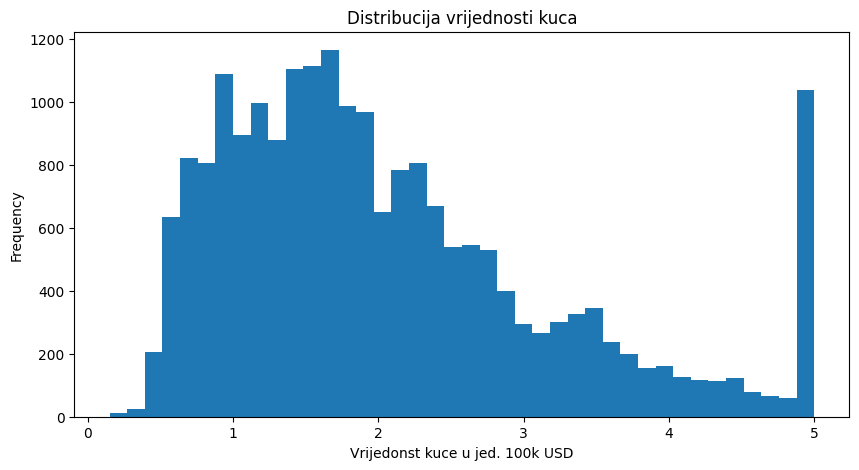

In [14]:
df['MedHouseVal'].plot(
    kind='hist',
    bins=40,
    figsize=(10, 5),
    title='Distribucija vrijednosti kuca'
)

plt.xlabel('Vrijedonst kuce u jed. 100k USD')

In [15]:
price_treshold = df['MedHouseVal'].quantile(0.75)
price_treshold

np.float64(2.6472499999999997)

In [16]:
df['Expensive_area'] = np.where(
    df['MedHouseVal'] >= price_treshold,
    1,
    0
)

df['Expensive_area'].value_counts()

Expensive_area
0    15480
1     5160
Name: count, dtype: int64

In [17]:
df['Expensive_area'].value_counts(normalize=True)

Expensive_area
0   0.75
1   0.25
Name: proportion, dtype: float64

In [26]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X_class = df[features]
y_class = df['Expensive_area']

X_train_class, X_test_class, y_trian_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.25,
    random_state=42
)

In [27]:
class_model = DecisionTreeClassifier(max_depth=7, random_state=42)
class_model.fit(X_train_class, y_trian_class)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [28]:
y_pred_class = class_model.predict(X_test_class)

accuracy = accuracy_score(y_test_class, y_pred_class)
accuracy

0.8767441860465116

In [29]:
df_expensive = df[df['Expensive_area'] == 1].copy()
df_expensive

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Expensive_area
0,8.33,41.00,6.98,1.02,322.00,2.56,37.88,-122.23,4.53,1
1,8.30,21.00,6.24,0.97,"2,401.00",2.11,37.86,-122.22,3.58,1
2,7.26,52.00,8.29,1.07,496.00,2.80,37.85,-122.24,3.52,1
3,5.64,52.00,5.82,1.07,558.00,2.55,37.85,-122.25,3.41,1
4,3.85,52.00,6.28,1.08,565.00,2.18,37.85,-122.25,3.42,1
...,...,...,...,...,...,...,...,...,...,...
20506,6.95,8.00,6.87,1.04,"2,510.00",3.46,34.29,-118.73,2.77,1
20527,1.47,7.00,3.53,1.02,"4,479.00",8.89,38.54,-121.79,3.10,1
20531,5.96,17.00,6.87,1.10,808.00,2.83,38.58,-121.81,2.86,1
20533,4.24,13.00,6.35,1.05,"2,553.00",2.64,38.54,-121.67,3.27,1


In [30]:
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X_reg = df_expensive[features]
y_reg = df_expensive['Expensive_area']

X_train_reg, X_test_reg, y_trian_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

In [31]:
reg_model = RandomForestRegressor(max_depth=10, random_state=42)
reg_model.fit(X_train_reg, y_trian_reg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [32]:
y_pred_reg = reg_model.predict(X_test_reg)

In [36]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mae

0.0

In [37]:
r2 = r2_score(y_test_reg, y_pred_reg)
r2

1.0

In [39]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Expensive_area
count,"20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00","20,640.00"
mean,3.87,28.64,5.43,1.10,"1,425.48",3.07,35.63,-119.57,2.07,0.25
std,1.90,12.59,2.47,0.47,"1,132.46",10.39,2.14,2.00,1.15,0.43
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15,0.00
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20,0.00
50%,3.53,29.00,5.23,1.05,"1,166.00",2.82,34.26,-118.49,1.80,0.00
75%,4.74,37.00,6.05,1.10,"1,725.00",3.28,37.71,-118.01,2.65,0.25
max,15.00,52.00,141.91,34.07,"35,682.00","1,243.33",41.95,-114.31,5.00,1.00


In [41]:
new_area_df = pd.DataFrame({
    'MedInc': [8.3, 5.4, 9.7, 13.1, 1.5],
    'HouseAge': [2.0, 8.6, 15.0, 14.0, 45],
    'AveRooms': [5, 4, 6, 8, 9],
    'AveBedrms': [2, 1, 4, 6, 8],
    'Population': [9090, 987, 25000, 250, 9878],
    'AveOccup': [2, 4, 8, 6, 3],
    'Latitude': [45.5, 45.55, 45.78, 45.35, 45.4],
    'Longitude': [13.2, 14.5, 15.6, 16.1, 16.5]
})

new_area_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.30,2.00,5,2,9090,2,45.50,13.20
1,5.40,8.60,4,1,987,4,45.55,14.50
2,9.70,15.00,6,4,25000,8,45.78,15.60
3,13.10,14.00,8,6,250,6,45.35,16.10
4,1.50,45.00,9,8,9878,3,45.40,16.50


In [43]:
new_area_pred = class_model.predict(new_area_df)
new_area_pred

array([1, 0, 1, 1, 0])

In [57]:
new_area_df['predicted_class'] = np.where(
    new_area_pred == 1,
    1,
    0
)

new_area_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,predicted_class
0,8.30,2.00,5,2,9090,2,45.50,13.20,1
1,5.40,8.60,4,1,987,4,45.55,14.50,0
2,9.70,15.00,6,4,25000,8,45.78,15.60,1
3,13.10,14.00,8,6,250,6,45.35,16.10,1
4,1.50,45.00,9,8,9878,3,45.40,16.50,0


In [58]:
new_values = []

for i, row in new_area_df.iterrows():
    row_df = pd.DataFrame([row])
    
    if new_area_pred[i] == 1:
        new_area_pred_reg = reg_model.predict(row_df)
        new_values.append(new_area_pred_reg)
    else:
        pass


new_values

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- predicted_class
